<a href="https://colab.research.google.com/github/alexalvaradorojas/alexalvaradorojas.github.io/blob/master/IS_298C_Notebook_Workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🤖✨🐢 IS 298C Slow Scholarship: Research Design and Humanistic Computing (Tuesdays 2-4:50PM) | Instructor: Dr. Cindy Nguyen

# *An Interpretative Computational Approach to Reading Datasets Using  Forensic Qualitative Analysis - Notebook Workshop* | Guest Lecturer: Alejandro Alvarado Rojas, PhD Candidate

📝 **Description**:

This computational notebook provides an exploratory data analysis of [Meta-Kaggle](https://www.kaggle.com/datasets/kaggle/meta-kaggle). The analysis is organized based on [this academic study (Alvarado & Twyman, 2025)](https://journals.sagepub.com/doi/10.1177/14614448251359631). However, a key difference between the data used in the study and the data used for this workshop is that the Meta-Kaggle dataset used in this notebook was downloaded on October 2nd, 2025. The notebook is written in [Python code](https://www.python.org/doc/essays/blurb/) and requires no prior knowledge coding knowledge to perform the different analyses.

🎯 **Learning Objectives:**

This notebook should enable you to:

 1.   Leverage these descriptive and statistical analysis and data visualizations to inform modes of humanistic data critique, such as Forensic Qualitative Analysis (FQA)


🛠️**Relevant Resources:**

We will be using various computational, analytical, and literary resources to inform our investigation:

💻 *Computational*

* [What is Google Colab? (video)](https://youtu.be/inN8seMm7UI?si=yfhj7tup7qgi9f22)
*    [What is Meta-Kaggle?](https://www.kaggle.com/datasets/kaggle/meta-kaggle)
*    [Python as coding langauge](https://www.python.org/doc/essays/blurb/)
*    [Python packages for programming](https://medium.com/swlh/what-is-the-difference-between-a-module-a-package-a-library-and-a-dependency-b09ca8e83ce7)

🧮 *Analytical*

*  [Introduction to Statistics (video)](https://www.youtube.com/watch?v=MXaJ7sa7q-8)
*  [Data Visualization (video)](https://www.youtube.com/watch?v=uHRqkGXX55I)
*  [Basic Descriptive Statistical Measures](https://www.youtube.com/watch?v=mk8tOD0t8M0)

📚 *Literary*

*  [Article that demonstrates application of Forensic Qualitative Analysis (Chamption et al. 2019)](https://dl.acm.org/doi/pdf/10.1145/3359155)
*  [Article that conceptualizes dataset reading strategies (Poirier, 2021)](https://journals.sagepub.com/doi/full/10.1177/20539517211029322#_i22)

🤖 **GenAI Use Disclaimer:**

Code snippets were partially generated using ChatGPT and Claude. These GenAI tools were used for cleaning up original code and informing more optimal logics for processing the data.  


⚖️ **License:**

This notebook and all associated Python code are released under the MIT License
.
You are free to use, modify, and distribute this notebook for educational and research purposes, provided that proper credit is given to the original author.

The dataset used in this notebook, Meta-Kaggle
, is separately licensed by Kaggle and subject to its Terms of Use
. Redistribution of the dataset itself must follow Kaggle’s data licensing and attribution requirements.

This program is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

*© 2025 Alejandro Alvarado Rojas. Portions of this work draw from Alvarado & Twyman (2025), "Cultural Data Markets: Interpreting the Popularity of Public Datasets," New Media & Society.*


# ‼️Copy This Notebook to Your Own G-Drive and Download Locally

1. Go to 'File'> 'Select Copy in Drive' > Open Copy File
2. Go to 'File' > 'Download' > 'Download .ipnyb'

#  ▶️ How to Run Cells in Notebook

The cells in this notebook contain "chunks" of pre-generated code for manipulating data. You can run these cells by pressing the "***PLAY*** or **SHIFT+ENTER**" button.  

*   Cells with more code and large data files will take longer to process
*   Cells will run one at a time


![](https://raw.githubusercontent.com/alexalvaradorojas/computation-reading-datasets-workbook/main/image-assets/run_cell_instructions.png)

In [ ]:
# Click on the "Play" button to run this cell or use the shortcut SHIFT  + ENTER
print("Output: I ran my first cell!")

Output: I ran my first cell!


# ⚙️ Notebook Environment Setup

We need to load the relevant packages or "tools" for data processing, analysis, and visualization.


**⚠️ Make sure to run each cell in order**

In [ ]:
# Download files from Google Drive using public download links
import gdown

# Core data manipulation
import pandas as pd
import numpy as np

# Statistics
import scipy.stats as stats
from scipy.stats import pearsonr, spearmanr, shapiro, skew, kurtosis, levene, f_oneway, kruskal

# Visualization
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

# Display formatting
from IPython.display import display
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('darkgrid')

Next, we need to download the main CSV file. We will pull this file from Hugging Face.

⚠️ You may need to sign in to your Google Account to be able to access the CSV file

When you run the first cell, you will be asked to login into your Google account. Click on "Run anyway".

![](https://raw.githubusercontent.com/alexalvaradorojas/computation-reading-datasets-workbook/main/image-assets/run_cell_warning.png)


In [ ]:
# Load the main CSV file from Hugging Face
url = "https://huggingface.co/datasets/AAR-PhD/DH201_meta-kaggle_workshop/resolve/main/meta_kaggle_raw_main_df.csv"
main_df = pd.read_csv(url)
main_df.drop(columns=['Unnamed: 0'], inplace=True)

# Load the DatasetVotes.csv from Hugging Face
url_votes = "https://huggingface.co/datasets/AAR-PhD/IS_298C_DatasetVotes.csv/resolve/main/IS_298C_DatasetVotes_10_2_2025.csv"
votes_df = pd.read_csv(url_votes)

/tmp/ipykernel_4483/2756552081.py:3: DtypeWarning: Columns (16,20,24) have mixed types. Specify dtype option on import or set low_memory=False.
  main_df = pd.read_csv(url)


⚠️ The `'meta_kaggle_raw_main_df.csv'`  was already precprocessed by combining separate CSVs provided by Meta-Kaggle.This tutorial does not cover this stage due to computatinal limitations. The specific code for manipulating individual CSVs can be accessed [here](https://github.com/alexalvaradorojas/computation-reading-datasets-workbook/tree/main/preprocessing-Meta-Kaggle) to run it locally/on another computational platform.


# 1️⃣ Data Pre-processing

## 📈 Investigate Data Structure


We will familiarize with the structure of Meta-Kaggle dataset by exploring the rows, columns, and variable types

In [ ]:
# Examine the shape (number of rows x columns)
rows, cols = main_df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")

Number of rows: 540698
Number of columns: 32


In [ ]:
# Examine all columns/variables in the dataset
list(main_df.columns)

['Id',
 'CreatorUserId',
 'OwnerUserId',
 'OwnerOrganizationId',
 'CurrentDatasetVersionId',
 'CurrentDatasourceVersionId',
 'ForumId',
 'Type',
 'CreationDate',
 'LastActivityDate',
 'TotalViews',
 'TotalDownloads',
 'TotalVotes',
 'TotalKernels',
 'Medal',
 'MedalAwardDate',
 'DatasetId',
 'Description',
 'Title',
 'Subtitle',
 'LicenseName',
 'VersionNumber',
 'VersionChangesCount',
 'AllTags',
 'AllTagsCount',
 'NormViews',
 'NormVotes',
 'NormDownloads',
 'NormKernels',
 'CombinedScore',
 'LogCombinedScore',
 'Rank_CombinedScore']

💡 Key observations:

*   There are 540,698 rows, which should correspond to individual datasets
*   There are 32 columns or variables that describe some aspect of each dataset
*   Some datasets have either missing information (NaN) or reported 0 for some variables

We will take a closer look at how much information is missing or "mischaracterized" in our Meta-Kaggle dataset, and whether there are any duplicate dataset observations.

In [ ]:
# Check missing values for each column
print("Missing Values per Column:")
print("=" * 50)
missing_values = main_df.isnull().sum()
missing_percentage = (main_df.isnull().sum() / len(main_df)) * 100

# Create a summary dataframe
missing_summary = pd.DataFrame({
    'Missing_Count': missing_values,
    'Missing_Percentage': missing_percentage
})

# Sort by missing count (descending) and display
missing_summary = missing_summary.sort_values('Missing_Count', ascending=False)
print(missing_summary)

print("\n" + "=" * 50)
print(f"Total columns with missing values: {(missing_values > 0).sum()}")

Missing Values per Column:
                            Missing_Count  Missing_Percentage
OwnerOrganizationId                538051               99.51
AllTags                            529820               97.99
Medal                              519683               96.11
MedalAwardDate                     510315               94.38
Subtitle                           423039               78.24
Description                        422275               78.10
OwnerUserId                          2647                0.49
VersionNumber                         513                0.09
Title                                 503                0.09
LicenseName                           502                0.09
CurrentDatasourceVersionId            269                0.05
CurrentDatasetVersionId               258                0.05
Type                                    0                0.00
ForumId                                 0                0.00
Id                                      0  

💡 Key observations:

*   Few datasets are published by organizations
*   Most datasets are not part of competitions
*   Most datasets are missing a subtitle and description
*   Some datasets were generated before tracking ownership
*   Some dasets are missing a title, license, and version ID
*   All datasets have some level of interaction (views, votes, downloads, kernels/projects)



❓ How might we visualize these "silences" or missing information?

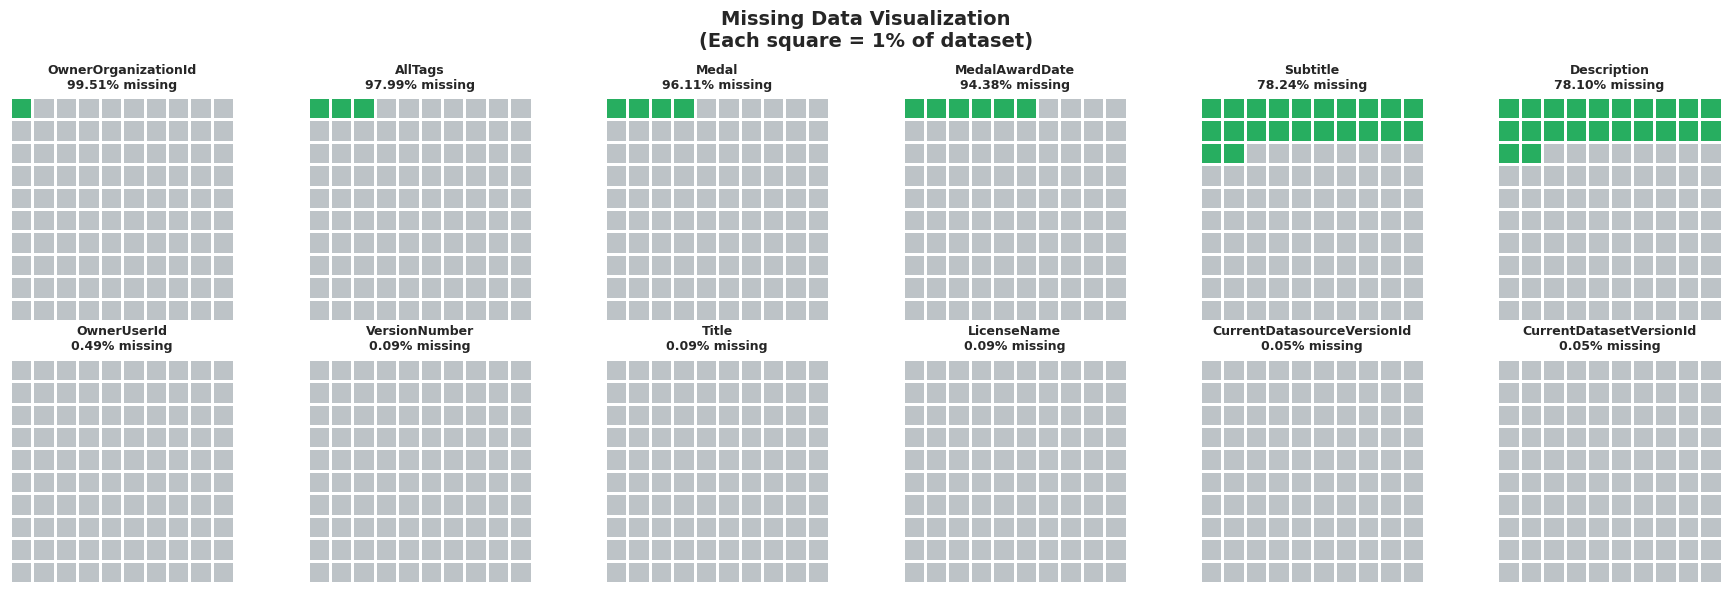

In [ ]:
# "Waffle Chart"
# Filter for columns with missing data and sort
missing_only = missing_summary[missing_summary['Missing_Percentage'] > 0].sort_values('Missing_Percentage', ascending=False)

# Create waffle charts
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
axes = axes.flatten()

for idx, (col_name, row) in enumerate(missing_only.iterrows()):
    # Create 10x10 grid
    grid = np.zeros((10, 10))
    flat_grid = grid.flatten()
    present_cells = 100 - int(row['Missing_Percentage'])
    flat_grid[:present_cells] = 1
    np.sort(flat_grid)
    grid = flat_grid.reshape((10, 10))

    # Plot
    sns.heatmap(grid, cmap=['#bdc3c7', '#27ae60'], cbar=False, square=True,
                linewidths=1, linecolor='white', ax=axes[idx],
                xticklabels=False, yticklabels=False)
    axes[idx].set_title(f"{col_name}\n{row['Missing_Percentage']:.2f}% missing",
                        fontsize=9, fontweight='bold')

# Hide unused subplots
for i in range(len(missing_only), len(axes)):
    axes[i].axis('off')

fig.suptitle('Missing Data Visualization\n(Each square = 1% of dataset)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Let's check for duplicate rows or datasets

In [ ]:
# Check for duplicates in 'Id' column
print("\n" + "=" * 50)
print("Duplicate Check on 'Id' Column:")
print("=" * 50)

duplicate_count = main_df['Id'].duplicated().sum()
print(f"Number of duplicate Ids: {duplicate_count}")

if duplicate_count > 0:
    print(f"\nDuplicate Id values:")
    duplicate_ids = main_df[main_df['Id'].duplicated(keep=False)]['Id'].value_counts()
    print(duplicate_ids)
else:
    print("No duplicate Ids found - each Id is unique! ✓")

# Additional info
print("\n" + "=" * 50)
print(f"Total rows: {len(main_df)}")
print(f"Unique Ids: {main_df['Id'].nunique()}")


Duplicate Check on 'Id' Column:
Number of duplicate Ids: 0
No duplicate Ids found - each Id is unique! ✓

Total rows: 540698
Unique Ids: 540698


💡 There are 540,698 unique entires or rows, each corresponding to a unique dataset.

⚠️ We use 'Id' to identify unique dataset identifiers, after preprocessing other similar identifiers (e.g., ids generated from source compared to non-source datasets from the raw Meta-Kaggle CSVs)



Now, we want to "transform" these missing values so that we can run our statistical analysis. Note that we are keeping track of how much information is missing, even if most of the missing information or values is not relevant for this analysis (though it could be for another type of analysis!)



In [ ]:
# Create a copy dataframe with missing values replaced by 0's
print("\n" + "=" * 50)
print("Creating copy with missing values transformed to 0's...")
print("=" * 50)

main_no_missing_df = main_df.copy()
main_no_missing_df = main_no_missing_df.fillna(0)

# Verify the transformation
print("\nVerification:")
print(f"Original dataframe missing values: {main_df.isnull().sum().sum()}")
print(f"New dataframe missing values: {main_no_missing_df.isnull().sum().sum()}")

print("\nDataframe 'main_no_missing_df' created successfully! ✓")
print(f"Shape: {main_no_missing_df.shape}")

# Show table to verify changes
main_no_missing_df.head(10)


Creating copy with missing values transformed to 0's...

Verification:
Original dataframe missing values: 2947875
New dataframe missing values: 0

Dataframe 'main_no_missing_df' created successfully! ✓
Shape: (540698, 32)


,Id,CreatorUserId,OwnerUserId,OwnerOrganizationId,CurrentDatasetVersionId,CurrentDatasourceVersionId,ForumId,Type,CreationDate,LastActivityDate,TotalViews,TotalDownloads,TotalVotes,TotalKernels,Medal,MedalAwardDate,DatasetId,Description,Title,Subtitle,LicenseName,VersionNumber,VersionChangesCount,AllTags,AllTagsCount,NormViews,NormVotes,NormDownloads,NormKernels,CombinedScore,LogCombinedScore,Rank_CombinedScore
0,310,14069,0.00,1160.00,23498.00,23502.00,1838,Dataset,11/03/2016 13:21:36,02/06/2018,12089246,995129,12501,5571,1.00,11/06/2019,310,Context\n---------\n\nIt is important that cre...,Credit Card Fraud Detection,Anonymized credit card transactions labeled as...,"Database: Open Database, Contents: Database Co...",3.00,3,0,0,1.00,0.23,1.00,0.73,0.74,0.55,1
1,19,1,0.00,7.00,420.00,420.00,997,Dataset,01/12/2016 00:33:31,02/06/2018,2684143,761523,4413,7605,1.00,11/06/2019,19,The Iris dataset was used in R.A. Fisher's cla...,Iris Species,Classify iris plants into three species in thi...,CC0: Public Domain,2.00,2,0,0,0.22,0.08,0.77,1.00,0.52,0.42,2
2,228,1,0.00,7.00,482.00,482.00,1652,Dataset,10/06/2016 18:31:56,02/06/2018,3048278,700575,4748,3681,1.00,11/06/2019,228,## Context\n\nThis dataset is originally from ...,Pima Indians Diabetes Database,Predict the onset of diabetes based on diagnos...,CC0: Public Domain,1.00,1,"dentistry, drugs and medications, hospitals an...",3,0.25,0.09,0.70,0.48,0.38,0.32,3
3,434238,1571785,1571785.00,0.00,2654038.00,2698094.00,446914,Dataset,12/04/2019 05:57:54,12/04/2019,3613758,655791,9348,2234,1.00,01/17/2020,434238,### Other Platform's Datasets (Click on the lo...,Netflix Movies and TV Shows,Listings of movies and tv shows on Netflix - R...,CC0: Public Domain,5.00,5,0,0,0.30,0.17,0.66,0.29,0.36,0.30,4
4,1442,519516,519516.00,0.00,8172.00,8172.00,4272,Dataset,06/21/2017 21:36:28,02/06/2018,1439580,337021,3784,6476,1.00,11/06/2019,1442,### Context\n\nAfter watching [Somm](http://ww...,Wine Reviews,"130k wine reviews with variety, location, wine...",CC BY-NC-SA 4.0,4.00,4,0,0,0.12,0.07,0.34,0.85,0.34,0.30,5
5,17810,1314380,1314380.00,0.00,23812.00,23851.00,25540,Dataset,03/22/2018 05:42:41,03/22/2018,2863109,547127,7159,3303,1.00,11/06/2019,17810,### Context\n\nhttp://www.cell.com/cell/fullte...,Chest X-Ray Images (Pneumonia),"5,863 images, 2 categories",Other (specified in description),2.00,2,0,0,0.24,0.13,0.55,0.43,0.34,0.29,6
6,284,462330,462330.00,0.00,618.00,618.00,1788,Dataset,10/26/2016 08:17:30,02/06/2018,2563080,726341,6549,1848,1.00,11/06/2019,284,This dataset contains a list of video games wi...,Video Game Sales,"Analyze sales data from more than 16,500 games.",Unknown,2.00,2,0,0,0.21,0.12,0.73,0.24,0.33,0.28,7
7,180,711301,0.00,7.00,408.00,408.00,1547,Dataset,09/19/2016 20:27:05,02/06/2018,2398741,484259,3892,3501,1.00,11/06/2019,180,Features are computed from a digitized image o...,Breast Cancer Wisconsin (Diagnostic) Data Set,Predict whether the cancer is benign or malignant,CC BY-NC-SA 4.0,2.00,2,0,0,0.20,0.07,0.49,0.46,0.30,0.27,8
8,4549,1236717,1236717.00,0.00,466349.00,482208.00,10301,Dataset,11/13/2017 18:30:07,02/06/2018,2095869,285151,5778,4819,1.00,11/06/2019,4549,UPDATE: Source code used for collecting this d...,Trending YouTube Video Statistics,Daily statistics for trending YouTube videos,CC0: Public Domain,115.00,115,0,0,0.17,0.11,0.29,0.63,0.30,0.26,9
9,661950,1772071,1772071.00,0.00,2314697.00,2356116.00,676378,Dataset,05/18/2020 22:50:26,05/18/2020,960872,80622,54761,106,1.00,05/24/2021,661950,### Context\nThis dataset comes from this [spr...,Animal Crossing New Horizons Catalog,"A comprehensive inventory of ACNH items, villa...",CC0: Public Domain,3.00,3,0,0,0.08,1.00,0.08,0.01,0.29,0.26,10




---



# 2️⃣ Forensic Qualitative Analysis

## 💭 Interpretive Strategies for Reading Datasets

We will review three different interpretive strategies for reading datasets using Forensic Qualitative Analysis.

🕵️ Forensic Qualitative Analysis allows us to `“to imbue digital trace material with meaning through a detailed study
of the trace materials themselves, along with their context and connections with other
events and materials”` [(Champion et al., 2019: 7)]((https://dl.acm.org/doi/pdf/10.1145/3359155))

It is a method to re-construct contexts by tracing different elements that constitute an event or situation, similar to "detective work"

We will complement this approach with "Literal, Connotative, and Deconstructive" readings of datasets. In her article, [Poirier, 2021](https://journals.sagepub.com/doi/full/10.1177/20539517211029322#_i22) presents three strategies to reading datasets:

[![Alt text](https://raw.githubusercontent.com/alexalvaradorojas/computation-reading-datasets-workbook/main/image-assets/poirier_2021_strategies.png)](https://raw.githubusercontent.com/alexalvaradorojas/computation-reading-datasets-workbook/main/image-assets/poirier_2021_strategies.png)


### 🔍 Denotative Reading



*   How are variables defined in the original codebook or dictionary?
*   How are observations characterized according to categories (e.g., numerical, text, visual, date/time)
*   What information "makes up" these categories and variables?



### 🔍 Connotative Reading



*   How have the variables and observations changed over time?
*   Who created this dataset and for what purpose?
*   What are the specific conditions that prompted the production of this dataset?
*   What other materials help us contextualize the "life" of this dataset?



### 🔍 Deconstructive Reading



*  What are the silences or absences in the data and why are they important?
*  What are the politics in constructing variables and characterizing observations according to categories (e.g., numerical, text, visual, data/time?)
*  Who is and is not represented and how are these representations made durable?


## 💭 Identify Relevant Digital Traces from Platform and Dataset Content


With these strategies and guiding questions in mind, how might we trace datasets on Meta-Kaggle?



We can organize our analysis in terms of the relationship between Subject-Object dimensions of datasets, by treating them ***as if they are content***.

![](https://raw.githubusercontent.com/alexalvaradorojas/computation-reading-datasets-workbook/main/image-assets/table2_cultural_data_markets.png)

These "traces" were developed from the initial codebook below:

Click on the image to open the preliminary codebook in a new tab to zoom in.

Codebook:
[![Alt text](https://raw.githubusercontent.com/alexalvaradorojas/computation-reading-datasets-workbook/main/image-assets/initial_codebook_cultural_data_markets.png)](https://raw.githubusercontent.com/alexalvaradorojas/computation-reading-datasets-workbook/main/image-assets/initial_codebook_cultural_data_markets.png)




## 📈 Exploratory Statistical Analysis to Inform the Tracing Process

One way to begin our analysis is to move from "Big Data" to "Small Data". This means using our statistical analyses to inform which datasets to trace.  

### 📈Descriptive Statistics on Popularity Metrics - Denotative Reading

In [ ]:
# Generate descriptive statistics on all Popularity metrics
print("\n" + "=" * 50)
print("Descriptive Statistics on Popularity Metrics:")
print("=" * 50)
print(main_no_missing_df[['TotalViews', 'TotalVotes', 'TotalDownloads', 'TotalKernels']].describe())


Descriptive Statistics on Popularity Metrics:
       TotalViews  TotalVotes  TotalDownloads  TotalKernels
count   540698.00   540698.00       540698.00     540698.00
mean      1901.27        4.41          260.11          1.65
std      28485.84       91.92         4509.97         34.61
min          0.00        0.00            0.00          0.00
25%         39.00        0.00            3.00          0.00
50%        146.00        0.00            9.00          0.00
75%        858.00        1.00           30.00          1.00
max   12089246.00    54761.00       995129.00       7605.00


Let's take a closer look at the sub-sample of datasets that are most popular on these dimensions.

In [ ]:
# Select columns of interest (metadata)
selected_columns = [
    'DatasetId',
    'Title',
    'TotalViews',
    'TotalVotes',
    'TotalDownloads',
    'TotalKernels',
    'Rank_CombinedScore',
    'CreationDate',
    'LastActivityDate'
]

# Sub-sample from main table
fqa_df = main_no_missing_df[selected_columns]
fqa_df = fqa_df.head(10)
fqa_df

,DatasetId,Title,TotalViews,TotalVotes,TotalDownloads,TotalKernels,Rank_CombinedScore,CreationDate,LastActivityDate
0,310,Credit Card Fraud Detection,12089246,12501,995129,5571,1,11/03/2016 13:21:36,02/06/2018
1,19,Iris Species,2684143,4413,761523,7605,2,01/12/2016 00:33:31,02/06/2018
2,228,Pima Indians Diabetes Database,3048278,4748,700575,3681,3,10/06/2016 18:31:56,02/06/2018
3,434238,Netflix Movies and TV Shows,3613758,9348,655791,2234,4,12/04/2019 05:57:54,12/04/2019
4,1442,Wine Reviews,1439580,3784,337021,6476,5,06/21/2017 21:36:28,02/06/2018
5,17810,Chest X-Ray Images (Pneumonia),2863109,7159,547127,3303,6,03/22/2018 05:42:41,03/22/2018
6,284,Video Game Sales,2563080,6549,726341,1848,7,10/26/2016 08:17:30,02/06/2018
7,180,Breast Cancer Wisconsin (Diagnostic) Data Set,2398741,3892,484259,3501,8,09/19/2016 20:27:05,02/06/2018
8,4549,Trending YouTube Video Statistics,2095869,5778,285151,4819,9,11/13/2017 18:30:07,02/06/2018
9,661950,Animal Crossing New Horizons Catalog,960872,54761,80622,106,10,05/18/2020 22:50:26,05/18/2020


**💡 Key observations:**

*   Credit Card Fraud Detection dataset reported largest number of Views and Downloads
*   Iris Species dataset reported largest number of Kernels (projects)
*   Animal Crossing New Horizons Catalog reported largest number of Votes
*   Overall, Credit Card Fraud detection was the most popular dataset

❓ Why does **Credit Card Fraud Detection** rank highest on nearly all engagement variables? In other words, why might this dataset be so popular?

We simply cannot answer this question by relying our statistical anlaysis. We must look at at its Data Card on Kaggle to contextualize our anlaysis.

### 📈 Popularity Metrics Over Time for Top 10 Datasets - Denotative Reading


Next, we will observe the popularity voting activity overtime.

In [ ]:
# Select columns of interest (metadata)
selected_columns = [
    'DatasetId',
    'CurrentDatasetVersionId',
    'CurrentDatasourceVersionId',
    'Title',
    'TotalViews',
    'TotalVotes',
    'TotalDownloads',
    'TotalKernels'
]

# Sub-sample from main table
time_vote_df = main_no_missing_df[selected_columns]
time_vote_df = time_vote_df.head(10)

# Create a dataframe that combines voting activity for the top 10 most popular datasets
# Merge A's 'Title' into B
votes_updated_df = votes_df.merge(
    time_vote_df[['CurrentDatasetVersionId', 'Title']],
    left_on='DatasetVersionId',
    right_on='CurrentDatasetVersionId',
    how='right'
)

# Remove the duplicate 'Dataset Id' column
votes_updated_df = votes_updated_df.drop(columns=['DatasetVersionId'])
votes_updated_df.head(5)

,Id,UserId,VoteDate,CurrentDatasetVersionId,Title
0,80357,513939,03/23/2018,23498.00,Credit Card Fraud Detection
1,80379,1742981,03/23/2018,23498.00,Credit Card Fraud Detection
2,80401,1691636,03/23/2018,23498.00,Credit Card Fraud Detection
3,80437,499159,03/23/2018,23498.00,Credit Card Fraud Detection
4,80473,1748625,03/23/2018,23498.00,Credit Card Fraud Detection


We will display the voting activity over time using a line chart.

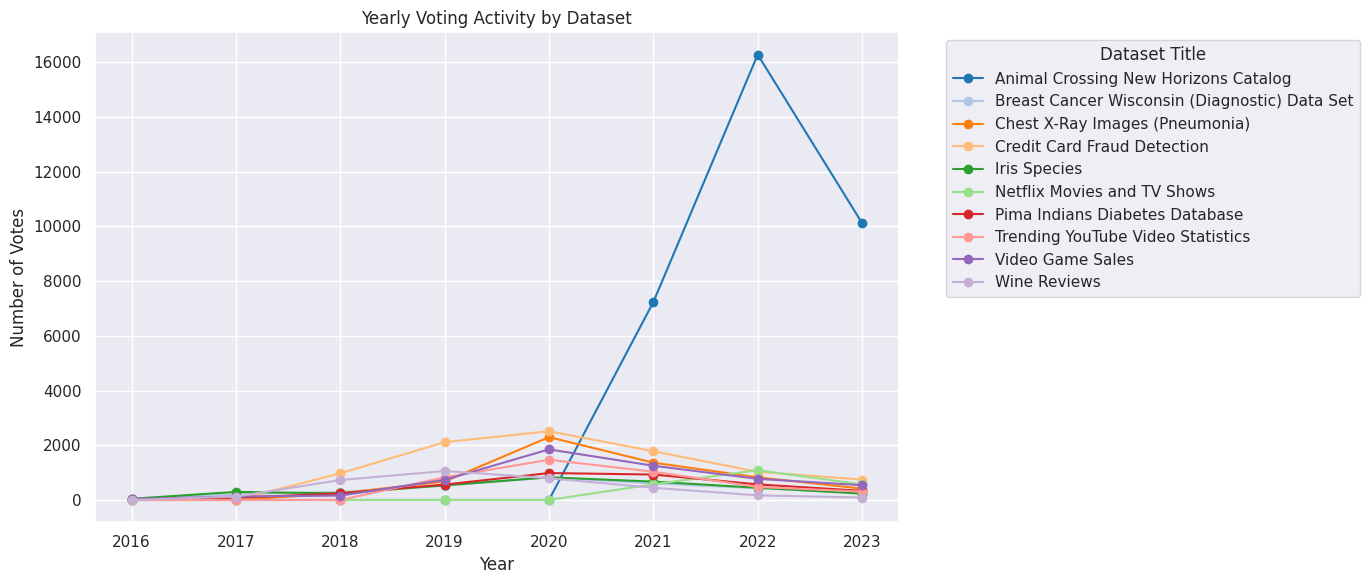

In [ ]:
# Ensure VoteDate is datetime
votes_updated_df['VoteDate'] = pd.to_datetime(votes_updated_df['VoteDate'])

# Extract year
votes_updated_df['Year'] = votes_updated_df['VoteDate'].dt.year

# Group by Title and Year, count votes
yearly_votes = votes_updated_df.groupby(['Title', 'Year']).size().reset_index(name='VoteCount')

# Pivot for plotting
votes_pivot_df = yearly_votes.pivot(index='Year', columns='Title', values='VoteCount').fillna(0)

# Set up plot
plt.figure(figsize=(14, 6))
sns.set(style="darkgrid")

# Get tab20 color palette
colors = plt.cm.tab20.colors
num_colors = len(colors)

# Plot each line with a tab20 color
for i, title in enumerate(votes_pivot_df.columns):
    plt.plot(votes_pivot_df.index, votes_pivot_df[title], marker='o', label=title, color=colors[i % num_colors])

# Format plot
plt.title("Yearly Voting Activity by Dataset")
plt.xlabel("Year")
plt.ylabel("Number of Votes")
plt.legend(title='Dataset Title', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 🔍 Tracing Data Cards on Kaggle - Connotative Reading

\We look up the dataset name on [Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud):

![](https://raw.githubusercontent.com/alexalvaradorojas/computation-reading-datasets-workbook/main/image-assets/credit_card_fraud_data_card.png)

📍 Guiding questions for FQA of datasets tracing different aspects of the Data Cards:

*   Who is the creator of the dataset? Who is the maintainer? Is this an invidiual, an organization, or a set of collaborators?
*   When was the dataset first published on Kaggle? When was it first created? When was it last updated?
*   Why was this dataset created? Is it solving a social or industry problem, or both?
*  Is this dataset derived from other datasets or is it an original dataset?
*  What specific materials or applications have been created from this dataset?
*  How are the subjects represented in this dataset protected?
*  What are the terms of dataset use, re-use, and distribution?

💡 Key observations:
* Financial industries have been a key investor in the development of machine learning techninques
* It was created from a public-private partnership
* It is also referenced within the community as a "standard" dataset for learning
* It is well-documented, making it easier to use
* Its last maintenance was in 2021, yet it continues to be relevant today
* Bank customers personal identifiable information has been removed and aggregated into a synthetic dataset



---



## 🔍 Deconstructing Dataset Traces from Meta-Kaggle - Deconstructive Reading

⚡What are the politics of the most popular datasets and their relationship to Meta-Kaggle, and broader context/events/world?

*  Political economy of dataset production, distribution and consumption
*  Scientification of "fraud", but what about conditions that give rise to it? how might some populations be more affected than others?
*  Popularity may reproduce inequalities
*  Toward more dynamic metadata justice





---



# 3️⃣ Activity Overview

Now, you will select one of the top 10 most popular datasets from the sub-sample and attempt FQA using the Dataset reading strategies

In [ ]:
# Display top 10 most popular datasets
fqa_df

,DatasetId,Title,TotalViews,TotalVotes,TotalDownloads,TotalKernels,Rank_CombinedScore,CreationDate,LastActivityDate
0,310,Credit Card Fraud Detection,12089246,12501,995129,5571,1,11/03/2016 13:21:36,02/06/2018
1,19,Iris Species,2684143,4413,761523,7605,2,01/12/2016 00:33:31,02/06/2018
2,228,Pima Indians Diabetes Database,3048278,4748,700575,3681,3,10/06/2016 18:31:56,02/06/2018
3,434238,Netflix Movies and TV Shows,3613758,9348,655791,2234,4,12/04/2019 05:57:54,12/04/2019
4,1442,Wine Reviews,1439580,3784,337021,6476,5,06/21/2017 21:36:28,02/06/2018
5,17810,Chest X-Ray Images (Pneumonia),2863109,7159,547127,3303,6,03/22/2018 05:42:41,03/22/2018
6,284,Video Game Sales,2563080,6549,726341,1848,7,10/26/2016 08:17:30,02/06/2018
7,180,Breast Cancer Wisconsin (Diagnostic) Data Set,2398741,3892,484259,3501,8,09/19/2016 20:27:05,02/06/2018
8,4549,Trending YouTube Video Statistics,2095869,5778,285151,4819,9,11/13/2017 18:30:07,02/06/2018
9,661950,Animal Crossing New Horizons Catalog,960872,54761,80622,106,10,05/18/2020 22:50:26,05/18/2020


## 🧩 Instructions:

1. Select a dataset from the top 10 most popular dataset list
2. Perform a Denotative reading with the information available
3. Perform a Connotative reading by examining its Data Card directly on Kaggle
4. Perform a Deconstructive reading based on the reconstruction of its context from the Connotative reading


### 🔍 Denotative Reading

* What do the popularity metrics tell you about this dataset?
* What other variables or measures do you think would help understand the influence of this dataset?


### 🔍 Connotative Reading

*   After examining the dataset's Data Card on Kaggle, what information could explain its score across popularity metrics?
*   Are there specific important changes made to the dataset metioned by the curators?
*   Who is involved in creating and curating this dataset?
*   What conditions or events led to dataset creation?
*   Are there other materials to help contextualize the "life" of this dataset?

### 🔍 Deconstructive Reading

*  Is there information about what information was left out or transformed in the dataset? Is this information about people?
*  How might the political and economic conditions characterize naming practices/conventions about this dataset?
*  Have representations of people/events in the dataset changed over time?  

#🌟 Well done!